
# IND320 - Project 1: Data to Decision
**Student:** Giorgio Crupi  
**GitHub Repository:** [https://github.com/giorgiocrupi/giorgiocrupi-ind320-project1]  
**Streamlit App:** [https://giorgiocrupi-giorgiocrupi-ind320-project1-app-4zntut.streamlit.app/]

**Screen recording** [https://nmbu.cloud.panopto.eu/Panopto/Pages/Viewer.aspx?id=f19bfc4e-646f-4ff6-96cd-b4d400a2c61f]



## AI Usage Declaration
During this project, Artificial Intelligence was utilized as a guided programming assistant. This was my first time developing in Visual Studio Code and working with Python, as my only prior programming background is in Java. However, this foundational knowledge allowed me to clearly understand the underlying logic and structure of the AI-generated solutions. Rather than blindly applying the code, I manually reviewed, tested, and adjusted every script, making it a strict priority to fully comprehend the technical mechanics behind every step. Transitioning to a new language and a new development environment has been a significant but highly rewarding challenge, and I am genuinely enjoying the hands-on, practical nature of this project.

---

## Mandatory Work Report

Mandatory Work Report

Starting the IND320 - Data to Decision course, my first practical goal was to build a reliable and reproducible workflow from scratch. Working with the Norwegian water reservoirs dataset, the first step is to have a stable environment. I set up my local workspace on macOS using Visual Studio Code and uv to securely lock library versions. To complete the pipeline, I configured a Git repository connected to GitHub. This version control setup not only tracked my daily progress but also enabled a seamless, automated deployment directly to the Streamlit Community Cloud, making the final application accessible and stable.

The initial data exploration was conducted within a Jupyter Notebook. Using the Pandas library, I imported the reservoirs.csv dataset. Since the original headers were in Norwegian, I used a dictionary mapping to translate them into English. A critical preprocessing step was constructing a proper Datetime index by concatenating the isolated ISO year and week values, which was strictly required for accurate time-series plotting.

To avoid visual artifacts caused by overlapping geographic area data within the same week, I used Pandas’ groupby function to calculate the national weekly average. Initially, I utilized a for loop to plot each numeric metric individually. This step successfully visualized their independent behaviors, clearly revealing the distinct seasonal wave cycles of the reservoirs. However, data visualization presented a significant scaling challenge when trying to compare them on a single chart. The dataset contains metrics with drastically different magnitudes, such as capacity in absolute Terawatt-hours versus fill rates as fractional percentages. Plotting these raw variables on a single y-axis severely distorted the smaller values. To resolve this, I applied Min-Max scaling to normalize all metrics between 0 and 1, allowing for an accurate visual comparison of their chronological trends.

The analytical logic was then migrated to a multi-page Streamlit web application, structured across separate Python files to ensure a modular architecture. The application features a data table integrating Streamlit's LineChartColumn to display raw data sparklines for the first available month, highlighting intra-month volatility. The core interactive component is the plotting page, which implements a select_slider for dynamic temporal filtering and a selectbox for metric selection. When 'All Columns' is selected, the application automatically applies the Min-Max normalization logic developed in the notebook. Finally, a placeholder page was included to satisfy the project's structural.

In [59]:
#Using the Pandas library, I imported the reservoirs.csv dataset.
import pandas as pd


# Read the CSV to inspect the headers
# Since the notebook was structured within a dedicated notebooks subdirectory, I utilized a relative path (../) to access the root-level data file.
df = pd.read_csv('../reservoirs.csv')

#inspection revealed the raw dataset structure and highlighted that the original column headers were in Norwegian.
df.head()

,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Read the reservoirs.csv file using Pandas.
# We use '../' because the notebook is in the 'notebooks' folder and the CSV is in the root directory.
df = pd.read_csv('../reservoirs.csv')

# 2. Rename the headers to understandable English for global readability.
column_translation = {
    'dato_Id': 'Date_Id', 'omrType': 'Area_Type', 'omrnr': 'Area_Number',
    'iso_aar': 'Year', 'iso_uke': 'Week', 'fyllingsgrad': 'Fill_Rate',
    'kapasitet_TWh': 'Capacity_TWh', 'fylling_TWh': 'Filled_TWh',
    'neste_Publiseringsdato': 'Next_Publishing_Date',
    'fyllingsgrad_forrige_uke': 'Fill_Rate_Last_Week',
    'endring_fyllingsgrad': 'Fill_Rate_Change'
}
df.rename(columns=column_translation, inplace=True)

# Construct a continuous Datetime column required for time-series plotting.
# Since the raw data only provides isolated ISO Year and Week, we concatenate them 
# with '-1' (representing Monday) and use the '%G-%V-%u' directive to instruct 
# Pandas to correctly parse the ISO year, ISO week, and weekday into a proper Date.
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Week'].astype(str) + '-1', format='%G-%V-%u')

# 3. Print its content in a relevant manner.
print("Dataset Overview (First 5 Rows):")
display(df.head())

print("\nDataset Information Summary:")
display(df.info())

Dataset Overview (First 5 Rows):


,Date_Id,Area_Type,Area_Number,Year,Week,Fill_Rate,Capacity_TWh,Filled_TWh,Next_Publishing_Date,Fill_Rate_Last_Week,Fill_Rate_Change,Date
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833,1995-08-28
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046,2020-11-09
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694,2011-08-22
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157,1998-06-29
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301,2011-03-21



Dataset Information Summary:
<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date_Id               14877 non-null  str           
 1   Area_Type             14877 non-null  str           
 2   Area_Number           14877 non-null  int64         
 3   Year                  14877 non-null  int64         
 4   Week                  14877 non-null  int64         
 5   Fill_Rate             14877 non-null  float64       
 6   Capacity_TWh          14877 non-null  float64       
 7   Filled_TWh            14877 non-null  float64       
 8   Next_Publishing_Date  14877 non-null  str           
 9   Fill_Rate_Last_Week   14877 non-null  float64       
 10  Fill_Rate_Change      14877 non-null  float64       
 11  Date                  14877 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(5), int64(3), str(3)
memo

None

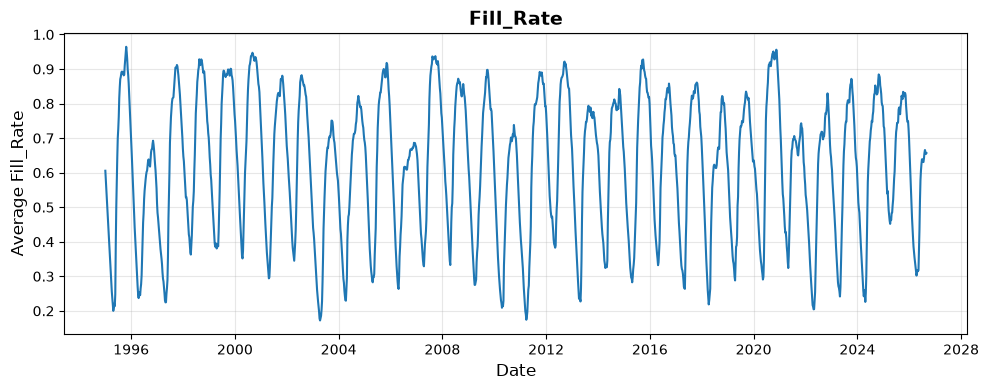

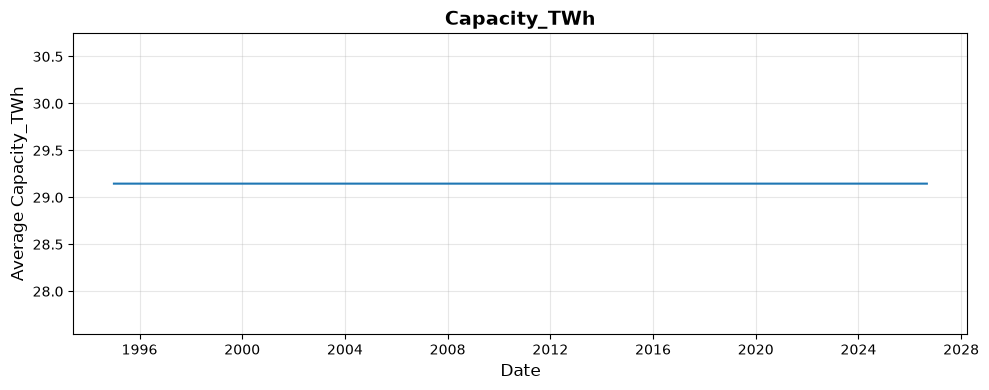

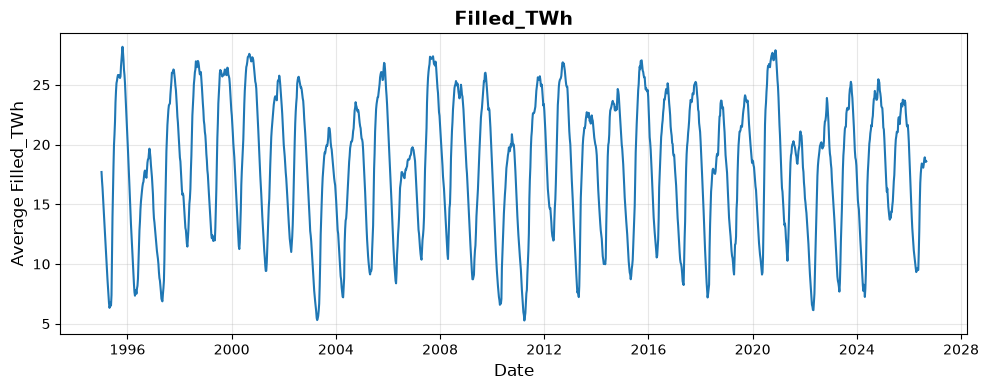

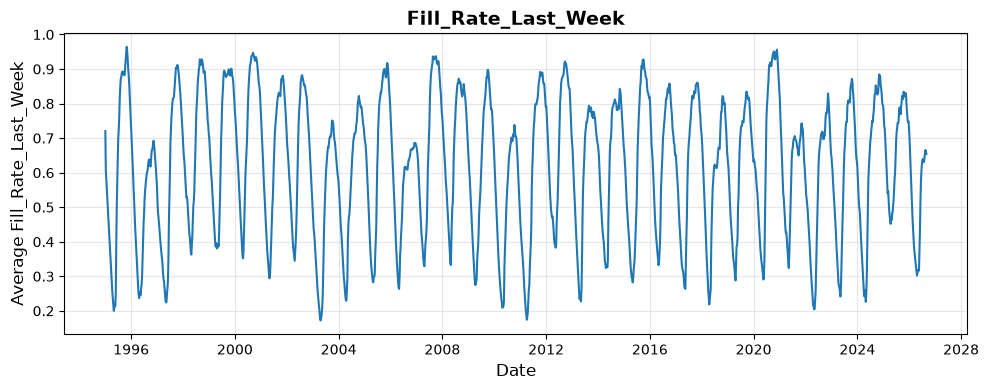

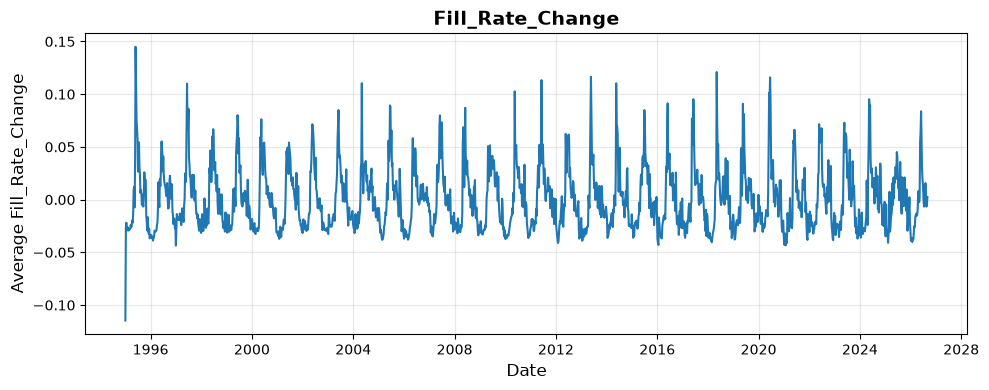

In [61]:
# Aggregate data: Group by Date and calculate the mean for all numeric metrics.
numeric_columns = ['Fill_Rate', 'Capacity_TWh', 'Filled_TWh', 'Fill_Rate_Last_Week', 'Fill_Rate_Change']
# This approach includes ALL areas without filtering, displaying a clean national average.
df_national = df.groupby('Date')[numeric_columns].mean().reset_index()

# Graph each column separately representing the national trend
for col in numeric_columns:
    plt.figure(figsize=(10, 4))
    plt.plot(df_national['Date'], df_national[col], color='#1f77b4', linewidth=1.5)
    plt.title(f'{col}', fontsize=14, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel(f'Average {col}', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

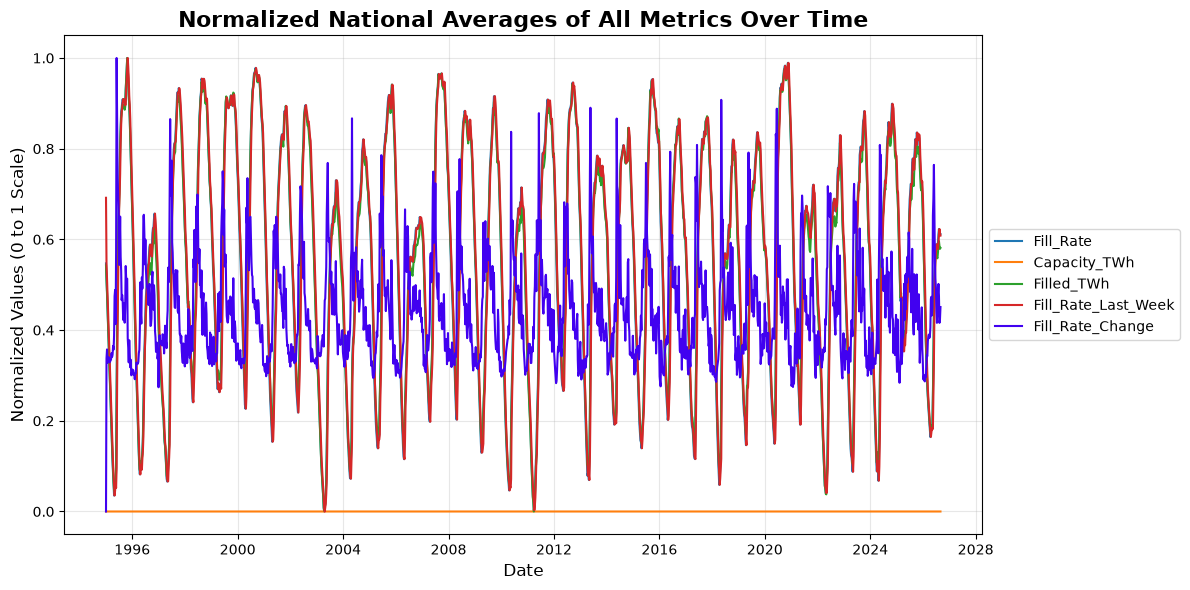

In [62]:
# Aggregate data to get the national average for all areas
df_national = df.groupby('Date')[numeric_columns].mean().reset_index()

# Normalize the data (Min-Max scaling) to plot everything on a single axis naturally
# This scales all metrics between 0 and 1, preserving their trends without scale distortion
df_normalized = df_national.copy()
for col in numeric_columns:
    min_val = df_national[col].min()
    max_val = df_national[col].max()
    # Avoid division by zero in case a column has a constant value
    if max_val != min_val:
        df_normalized[col] = (df_national[col] - min_val) / (max_val - min_val)
    else:
        df_normalized[col] = 0

# Plot all normalized columns together in a single graph
plt.figure(figsize=(12, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', "#4101f0"]

for i, col in enumerate(numeric_columns):
    plt.plot(df_normalized['Date'], df_normalized[col], label=col, color=colors[i], linewidth=1.5)
    
plt.title('Normalized National Averages of All Metrics Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Normalized Values (0 to 1 Scale)', fontsize=12)

# Place the legend outside the plot so it doesn't cover the data lines
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# App streamlit
**Starting page** 

```python
import streamlit as st

# Page configuration
st.set_page_config(page_title="IND320 - Project 1", layout="wide")

st.title("Norwegian Water Reservoirs Dashboard")
st.write("Welcome to the interactive dashboard for IND320 Project 1.")
st.write("Please use the sidebar menu to navigate through the pages.")



**Table page**

```python
import streamlit as st
import pandas as pd

st.set_page_config(page_title="Data Table", layout="wide")
st.title("Imported Data Overview")

@st.cache_data
def load_data():
    df = pd.read_csv('reservoirs.csv')
    
    column_translation = {
        'dato_Id': 'Date_Id', 'omrType': 'Area_Type', 'omrnr': 'Area_Number',
        'iso_aar': 'Year', 'iso_uke': 'Week', 'fyllingsgrad': 'Fill_Rate',
        'kapasitet_TWh': 'Capacity_TWh', 'fylling_TWh': 'Filled_TWh',
        'neste_Publiseringsdato': 'Next_Publishing_Date',
        'fyllingsgrad_forrige_uke': 'Fill_Rate_Last_Week',
        'endring_fyllingsgrad': 'Fill_Rate_Change'
    }
    df.rename(columns=column_translation, inplace=True)
    
    # Convert ISO Year and Week to a standard Date and Month string
    df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Week'].astype(str) + '-1', format='%G-%V-%u')
    df['Month_Str'] = df['Date'].dt.strftime('%Y-%m')
    return df

df = load_data()

# Isolate the first available month in the dataset
first_month = df['Month_Str'].min()
st.write(f"### Trend Analysis for the First Month: {first_month}")

# Filter dataframe for the first month only
df_first_month = df[df['Month_Str'] == first_month]

numeric_columns = ['Fill_Rate', 'Capacity_TWh', 'Filled_TWh', 'Fill_Rate_Last_Week', 'Fill_Rate_Change']

summary_data = []
for col in numeric_columns:
    # Extract ALL raw records for the month 
    # We use dropna() and astype(float) to prevent Streamlit rendering crashes.
    raw_values = df_first_month[col].dropna().astype(float).tolist()
    
    summary_data.append({
        "Variable Name": col,
        "Trend (First Month)": raw_values
    })

summary_df = pd.DataFrame(summary_data)

# Display dataframe using LineChartColumn for the raw values
st.dataframe(
    summary_df,
    column_config={
        "Variable Name": st.column_config.TextColumn("Column Name", width="medium"),
        "Trend (First Month)": st.column_config.LineChartColumn(
            "Trend Line",
            help="Raw data points for the first month (all areas)"
        )
    },
    hide_index=True,
    use_container_width=True
)

**Plot page**

```python
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(page_title="Interactive Plot", layout="wide")
st.title("Interactive Data Visualization")

@st.cache_data
def load_data():
    df = pd.read_csv('reservoirs.csv')
    
    column_translation = {
        'dato_Id': 'Date_Id', 'omrType': 'Area_Type', 'omrnr': 'Area_Number',
        'iso_aar': 'Year', 'iso_uke': 'Week', 'fyllingsgrad': 'Fill_Rate',
        'kapasitet_TWh': 'Capacity_TWh', 'fylling_TWh': 'Filled_TWh',
        'neste_Publiseringsdato': 'Next_Publishing_Date',
        'fyllingsgrad_forrige_uke': 'Fill_Rate_Last_Week',
        'endring_fyllingsgrad': 'Fill_Rate_Change'
    }
    df.rename(columns=column_translation, inplace=True)
    
    # Create Date and Month_Str columns for filtering
    df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Week'].astype(str) + '-1', format='%G-%V-%u')
    df['Month_Str'] = df['Date'].dt.strftime('%Y-%m')
    return df

df = load_data()

numeric_columns = ['Fill_Rate', 'Capacity_TWh', 'Filled_TWh', 'Fill_Rate_Last_Week', 'Fill_Rate_Change']

# --- WIDGET 1: Select Slider for Month Range ---
# Extract unique sorted months
unique_months = sorted(df['Month_Str'].unique())
first_month = unique_months[0]

# Using a tuple (first_month, first_month) creates a range slider defaulting to the first month
selected_months = st.select_slider(
    "Select a subset of months:",
    options=unique_months,
    value=(first_month, first_month)
)

# Filter dataframe based on the selected month range
mask = (df['Month_Str'] >= selected_months[0]) & (df['Month_Str'] <= selected_months[1])
df_filtered = df[mask]


# --- WIDGET 2: Selectbox for Columns ---
options = ['All Columns'] + numeric_columns
selected_col = st.selectbox("Choose a column to plot:", options=options)

st.write("---")

# --- PLOTTING ---
# Aggregate data by Date to calculate the national average and avoid visual artifacts
df_plot = df_filtered.groupby('Date')[numeric_columns].mean().reset_index()

# Set up the Matplotlib figure
fig, ax = plt.subplots(figsize=(12, 6))

if selected_col == 'All Columns':
    # Normalize data (Min-Max scaling) to make the graph natural despite different scales
    df_normalized = df_plot.copy()
    for col in numeric_columns:
        min_val = df_plot[col].min()
        max_val = df_plot[col].max()
        if max_val != min_val:
            df_normalized[col] = (df_plot[col] - min_val) / (max_val - min_val)
        else:
            df_normalized[col] = 0.5
            
    # Plot all normalized columns
    for col in numeric_columns:
        ax.plot(df_normalized['Date'], df_normalized[col], label=col, linewidth=2)
        
    ax.set_ylabel("Normalized Values (0-1 Scale)", fontsize=12)
    ax.set_title(f"National Averages - All Columns ({selected_months[0]} to {selected_months[1]})", fontsize=16, fontweight='bold')

else:
    # Plot only the single selected column
    ax.plot(df_plot['Date'], df_plot[selected_col], color='#1f77b4', linewidth=2, label=selected_col)
    ax.set_ylabel(selected_col, fontsize=12)
    ax.set_title(f"{selected_col} Trend ({selected_months[0]} to {selected_months[1]})", fontsize=16, fontweight='bold')

# Formatting the plot (headers, axes, grid)
ax.set_xlabel("Date", fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc='best')
plt.xticks(rotation=45)
plt.tight_layout()

# Display the plot in Streamlit
st.pyplot(fig)

**Extra**

```python
import streamlit as st

st.set_page_config(page_title="Extra Features", layout="wide")

st.title("Extra Features (Dummy Page)")
st.write("This page serves as a placeholder to fulfill the four-page requirement for Project 1.")
